## Load Built-in Dataset

In [2]:
from surprise import Dataset, Reader

file_path = r"ml-1m\ratings.dat"

reader = Reader(line_format='user item rating timestamp', 
                sep="::")

data = Dataset.load_from_file(file_path=file_path,
                              reader=reader)

type(data)

surprise.dataset.DatasetAutoFolds

## Peeking Inside the Dataset


In [3]:
import pandas as pd

df = pd.read_csv(
    filepath_or_buffer=file_path,
    sep="::",
    names=["user_id", "movie_id", "rating", "timestamp"],   # custom column names
    engine='python'                                         # needed to handle the "::" separator properly
)

print(df.head(5))
print(f"The dataset has {df.shape[0]:,} ratings and {df.shape[1]} columns")

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291
The dataset has 1,000,209 ratings and 4 columns


## SVD Model Hyperparameter Tuning with RandomizedSearchCV


In [4]:
from surprise import SVD
from surprise.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_grid_svd = {
    "n_factors": randint(80, 150),      # Number of latent factors (hidden features)
    "n_epochs": randint(15, 40),        # Training iterations
    "lr_all": uniform(0.003, 0.008),    # Learning rate
    "reg_all": uniform(0.03, 0.1),      # Regularization
    "biased": [True, False]             # True = add user/movie bias offsets (avg rating tendencies), False = use only latent factors
}

rs_svd = RandomizedSearchCV(algo_class=SVD,
                            param_distributions=param_grid_svd,
                            n_iter=15,                           # Try 15 random combos
                            cv=3,                                   
                            measures=["rmse", "mae"],
                            random_state=42)

rs_svd.fit(data=data)

## Initialize SVD With Best Hyperparameters From Randomized Search


In [5]:
from surprise.model_selection import train_test_split

best_svd = SVD(**rs_svd.best_params['rmse'])

trainset, testset = train_test_split(data=data,
                                     test_size=0.2,
                                     random_state=42)

best_svd.fit(trainset)

## Evaluate SVD Model


In [6]:
from surprise import accuracy

svd_predictions = best_svd.test(testset)
svd_rmse = accuracy.rmse(predictions=svd_predictions)

RMSE: 0.8549


## KNN Hyperparameter Tuning with RandomizedSearchCV


In [30]:
from surprise.model_selection import RandomizedSearchCV
from surprise import KNNBaseline

param_grid_knn = {
    'k': [30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'msd'],
        'user_based': [True, False],
        'min_support': [3, 5]
    }
}

rs_knn = RandomizedSearchCV(algo_class=KNNBaseline,
                            param_distributions=param_grid_knn,
                            n_iter=5,
                            cv=2,
                            measures=["rmse", "mae"],
                            random_state=42
                            )

rs_knn.fit(data=data)

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine sim

## Initialize KNN With Best Hyperparameters From Randomized Search


In [31]:
best_knn = KNNBaseline(**rs_knn.best_params['rmse'])
best_knn.fit(trainset=trainset)

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.


## Evaluate KNN Model


In [32]:
knn_predictions = best_knn.test(testset=testset)
knn_rmse = accuracy.rmse(predictions=knn_predictions)

RMSE: 0.8842


## BaselineOnly Hyperparameter Tuning with RandomizedSearchCV


In [ ]:
from surprise import BaselineOnly

baseline_param_grid = {
    'bsl_options': {
        'method': ['als', 'sgd'],
        'reg_i': [5, 10],  # ALS: item regularization
        'reg_u': [10, 15], # ALS: user regularization  
        'reg': [0.01, 0.05], # SGD: regularization
        'learning_rate': [0.005, 0.01], # SGD: learning rate
        'n_epochs': [10, 20] # Both methods
    }
}

rs_baseline = RandomizedSearchCV(BaselineOnly,
                                   param_distributions=baseline_param_grid,
                                   n_iter=10,
                                   measures=['rmse', 'mae'],
                                   cv=3,
                                   random_state=42
                                   )

# Run the search
rs_baseline.fit(data)


Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...
Estimating biases using sgd...


## Initialize from surprise import BaselineOnly With Best Hyperparameters From Randomized Search


In [24]:
best_baseline = BaselineOnly(**rs_baseline.best_params["rmse"])
best_baseline.fit(trainset=trainset)

Estimating biases using als...


## Evaluate BaselineOnly Model

In [26]:
from surprise import accuracy

baseline_predictions = best_baseline.test(testset=testset)
baseline_rmse = accuracy.rmse(predictions=baseline_predictions)

RMSE: 0.9089


## SlopeOne Hyperparameter Tuning with RandomizedSearchCV


In [8]:
from surprise import SlopeOne
from surprise.model_selection import cross_validate

slopeone_model = SlopeOne()

slopeone_results = cross_validate(algo=slopeone_model,
                                  data=data,
                                  measures=["rmse", "mae"],
                                  cv=5,
                                  verbose=True)

slopeone_rmse = slopeone_results['test_rmse'].mean()
slopeone_mae = slopeone_results['test_mae'].mean()

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9059  0.9061  0.9058  0.9058  0.9085  0.9064  0.0010  
MAE (testset)     0.7146  0.7144  0.7140  0.7138  0.7148  0.7143  0.0004  
Fit time          13.69   15.11   13.51   13.77   13.46   13.91   0.61    
Test time         33.16   30.90   29.61   30.81   29.59   30.81   1.30    


## Evaluate SlopeOne Model

In [9]:
print(f"RMSE: {slopeone_rmse:.4f}")
print(f"MAE:  {slopeone_mae:.4f}")

RMSE: 0.9064
MAE:  0.7143


## RMSE Comparison Bar Chart

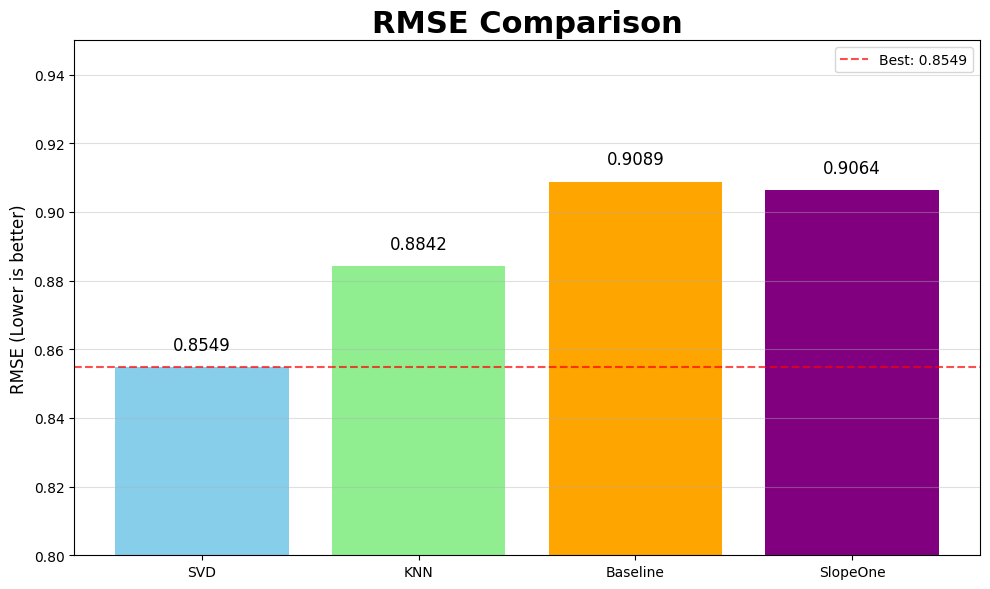

In [ ]:
import matplotlib.pyplot as plt

models = ["SVD", "KNN", "Baseline", "SlopeOne"]
values = [svd_rmse, knn_rmse, baseline_rmse, slopeone_rmse]

plt.figure(figsize=(10, 6))

plt.bar(x=models,
        height=values,
        color=['skyblue', 'lightgreen', 'orange', 'purple']
        )

plt.title(label="RMSE Comparison",
          fontweight="bold",
          fontsize=22)

plt.ylabel("RMSE (Lower is better)",
           fontsize=12)
# Add light horizontal grid lines
plt.grid(axis="y",
         alpha=0.4)

# Zoom y-axis 
plt.ylim(bottom=0.8, top=0.95)

# Add RMSE value labels on top of each bar
for index, value in enumerate(values):
    plt.text(x=index,                   # x-coordinate
             y=value + 0.005,           # y-coordinate + slight value to place it above the bar
             s=f"{value:.4f}",          # String
             ha="center",               # horizontal alignment
             fontsize=12)
    
# Find the best (lowest) RMSE value
min_rmse = min(values)

# Draw horizontal dashed line at the best RMSE value
plt.axhline(y=min_rmse,
            linestyle="--",
            color='red',
            alpha=0.7,
            label = f"Best: {min_rmse:.4f}"
            )

plt.tight_layout()
plt.legend()
plt.show()

## Evaluating The Best Model on Test Set

In [87]:
# Set the best model for evaluation
best_model = best_svd

# Loop through first 10 test cases
for i, (user, item, rating) in enumerate(testset[:10]): 

    # Generate prediction and roudn to 2 decimals
    pred = best_svd.predict(str(user), str(item)).est
    
    # Show only predictions with error <=1
    if abs(pred - rating) <= 1:
        print(f"User {user} → Item {item}: Real: {rating} → Predicted: {pred:.2f}")

User 3715 → Item 880: Real: 3.0 → Predicted: 2.40
User 2002 → Item 3072: Real: 4.0 → Predicted: 3.88
User 3332 → Item 2734: Real: 3.0 → Predicted: 3.45
User 3576 → Item 631: Real: 3.0 → Predicted: 2.67
User 2092 → Item 3247: Real: 3.0 → Predicted: 2.77
User 4610 → Item 2124: Real: 3.0 → Predicted: 3.23
User 398 → Item 3176: Real: 4.0 → Predicted: 3.56
User 4533 → Item 357: Real: 4.0 → Predicted: 3.44


## SVD Prediction Accuracy

In [90]:
counter = 0

# Loop through first 10 test cases
for i, (user, item, rating) in enumerate(testset):
    pred = best_svd.predict(str(user), str(item)).est
    
    # Show only predictions with error <=1
    if abs(pred - rating) <= 1:
        counter += 1

print(f"Predictions within 1.0: {counter} out of {len(testset)}\nAccuracy: {counter / len(testset) * 100:.2f}%")

Predictions within 1.0: 153751 out of 200042
Accuracy: 76.86%
